In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
cocoa_data = '/content/drive/MyDrive/Colab Notebooks/cocoa_data.csv' # Accessing data to be used
cf = pd.read_csv(cocoa_data)
cf.dtypes #Checking data types.


,0
DATE,object
OPEN,object
HIGH,object
LOW,object
CLOSE,object
ADJ. CLOSE,object
VOLUME,object


In [3]:
cf.size

1764

In [4]:
cf.head()#Accesing first 5 rows of the data

,DATE,OPEN,HIGH,LOW,CLOSE,ADJ. CLOSE,VOLUME
0,10-Jan-25,"10,823.00","10,920.00","10,525.00","10,570.00","10,570.00","10,908"
1,09-Jan-25,"11,103.00","11,513.00","10,605.00","10,927.00","10,927.00","10,908"
2,08-Jan-25,"11,009.00","11,315.00","10,345.00","10,453.00","10,453.00","10,690"
3,07-Jan-25,"11,291.00","11,568.00","11,164.00","11,210.00","11,210.00","5,582"
4,06-Jan-25,"11,423.00","11,882.00","11,066.00","11,377.00","11,377.00","8,022"


In [5]:
cf.isnull().sum()

,0
DATE,0
OPEN,0
HIGH,0
LOW,0
CLOSE,0
ADJ. CLOSE,0
VOLUME,0


In [6]:
cf = pd.read_csv(cocoa_data, thousands=',') # Changing vaiables from object data type to float.
summary = cf.describe()# Getting the mean and standard deviation of each of the variables.
del cf['DATE'] # Deleting the date column.
del cf['VOLUME'] # Deleting the volume column.
print(summary) # Displaying the mean, standard deviation, minimum, maximum, and the quartiles.

               OPEN          HIGH           LOW         CLOSE    ADJ. CLOSE
count    252.000000    252.000000    252.000000    252.000000    252.000000
mean    8390.063492   8607.980159   8206.940476   8422.761905   8422.761905
std     1787.765621   1848.026096   1716.927544   1775.106497   1775.106497
min     4210.000000   4280.000000   4199.000000   4274.000000   4274.000000
25%     7343.000000   7495.750000   7152.500000   7351.750000   7351.750000
50%     8285.000000   8489.000000   8149.000000   8322.000000   8322.000000
75%     9670.500000   9899.250000   9539.750000   9699.250000   9699.250000
max    12553.000000  12931.000000  11935.000000  12565.000000  12565.000000


CALCULATING THE MEDIAN OF INDIVIDUAL COLUMNS

In [7]:
# Median for OPEN column
median_value = cf["OPEN"].median()
print("The median value is: ", median_value)

The median value is:  8285.0


In [8]:
# Median for HIGH column
median_value = cf["HIGH"].median()
print("The median value is: ", median_value)

The median value is:  8489.0


In [9]:
# Median for LOW column
median_value = cf["LOW"].median()
print("The median value is: ", median_value)

The median value is:  8149.0


In [10]:
# Median for CLOSE column
median_value = cf["CLOSE"].median()
print("The median value is: ", median_value)

The median value is:  8322.0


In [11]:
# Median for ADJ. CLOSE column
median_value = cf["ADJ. CLOSE"].median()
print("The median value is: ", median_value)

The median value is:  8322.0


<ipython-input-12-302729dbbc81>:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cf['DATE'] = pd.to_datetime(cf['DATE'])


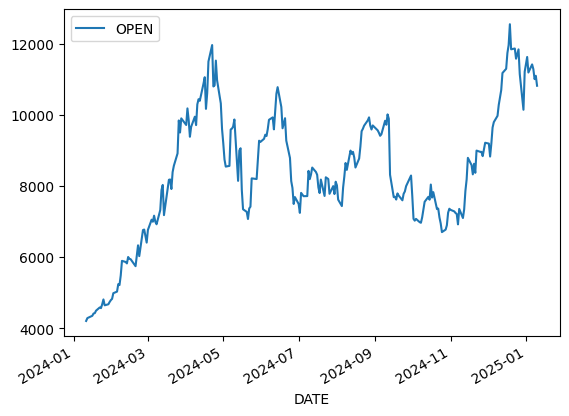

In [12]:
#Create a Line plot for each variable
cf = pd.read_csv(cocoa_data, thousands=',') # Changing vaiables from object data type to float.
cf['DATE'] = pd.to_datetime(cf['DATE'])
cf.plot(x='DATE', y='OPEN', kind='line')
plt.show()

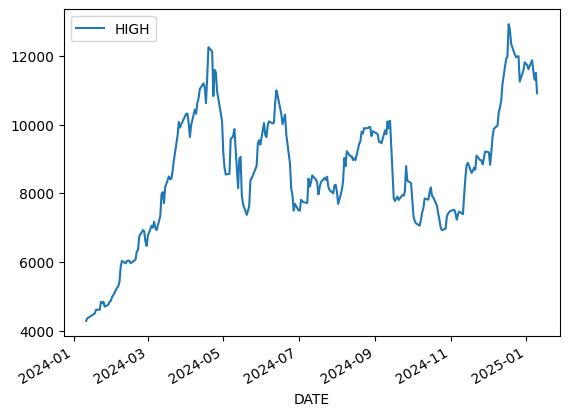

In [81]:
cf.plot(x='DATE', y='HIGH', kind='line')
cf['DATE'] = pd.to_datetime(cf['DATE'])
plt.show()

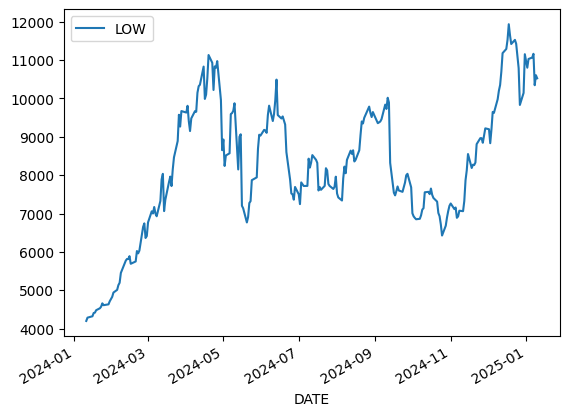

In [82]:
cf.plot(x='DATE', y='LOW', kind='line')
cf['DATE'] = pd.to_datetime(cf['DATE'])
plt.show()

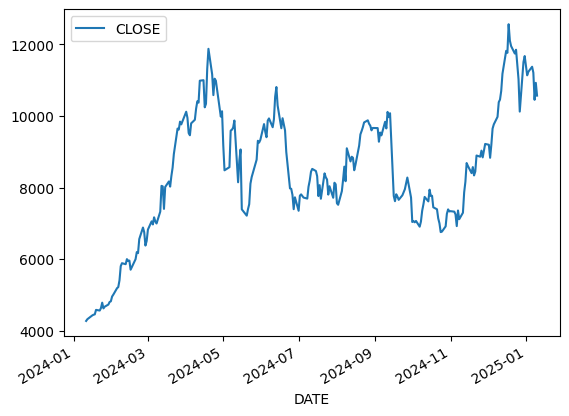

In [83]:
cf.plot(x='DATE', y='CLOSE', kind='line')
cf['DATE'] = pd.to_datetime(cf['DATE'])
plt.show()

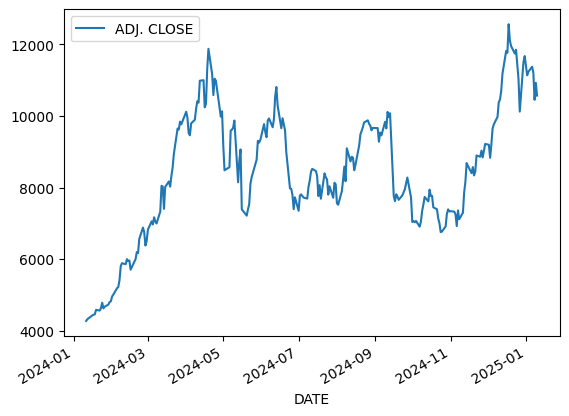

In [84]:
cf.plot(x='DATE', y='ADJ. CLOSE', kind='line')
cf['DATE'] = pd.to_datetime(cf['DATE'])
plt.show()

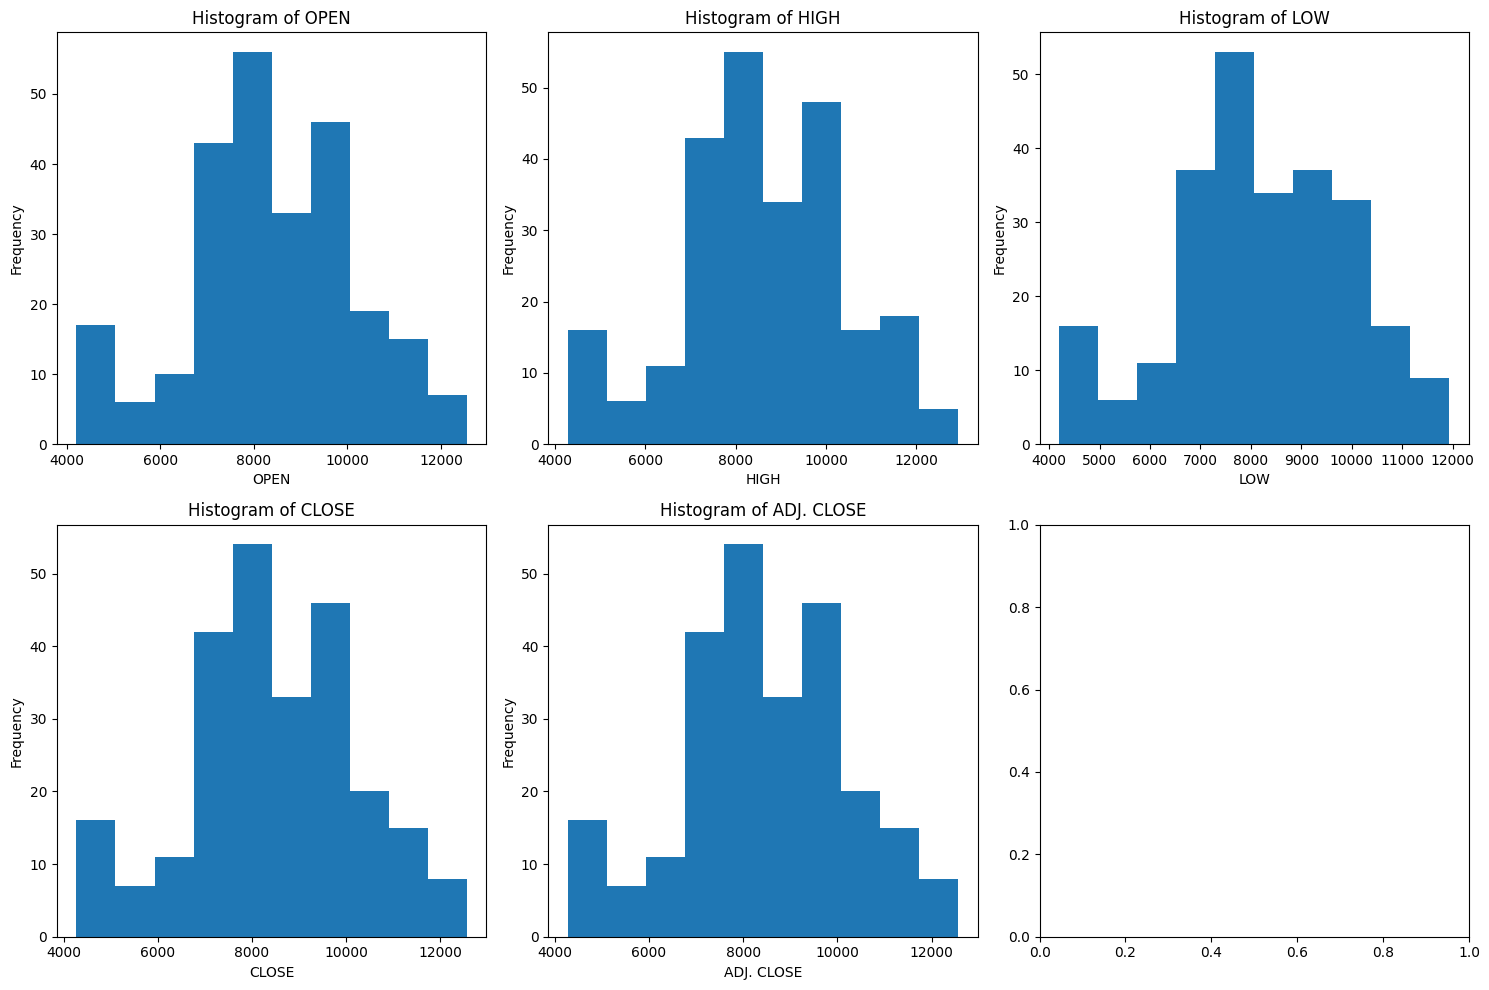

In [13]:
# Plotting a histogram for cf with columns: 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'ADJ. CLOSE'

# Create a figure and axes for the subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 rows, 3 columns

# Flatten the axes array for easier iteration
axes = axes.flatten()

# List of columns to create histograms for
columns = ['OPEN', 'HIGH', 'LOW', 'CLOSE', 'ADJ. CLOSE']

# Iterate through columns and create histograms
for i, col in enumerate(columns):
    axes[i].hist(cf[col], bins=10)  # Adjust bins as needed
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()

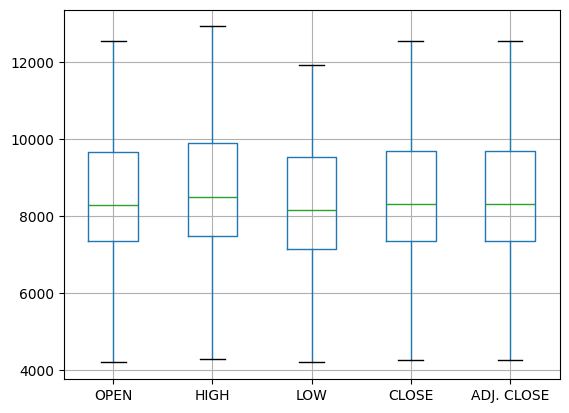

In [14]:
#Create boxplot for data.
boxplot = cf.boxplot(column=['OPEN', 'HIGH', 'LOW', 'CLOSE', 'ADJ. CLOSE'])

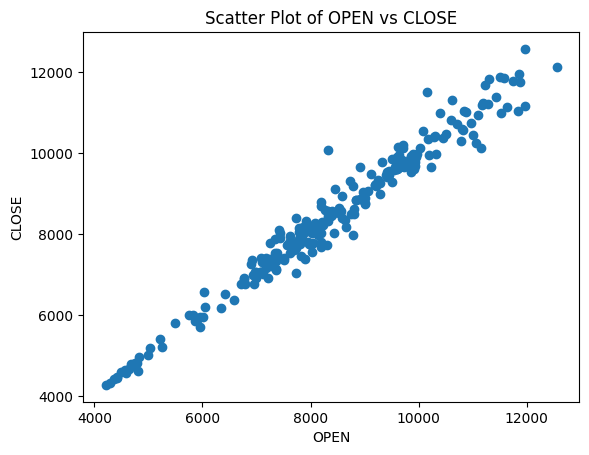

                OPEN      HIGH       LOW     CLOSE  ADJ. CLOSE
OPEN        1.000000  0.990706  0.991457  0.984493    0.984493
HIGH        0.990706  1.000000  0.985516  0.993839    0.993839
LOW         0.991457  0.985516  1.000000  0.990308    0.990308
CLOSE       0.984493  0.993839  0.990308  1.000000    1.000000
ADJ. CLOSE  0.984493  0.993839  0.990308  1.000000    1.000000


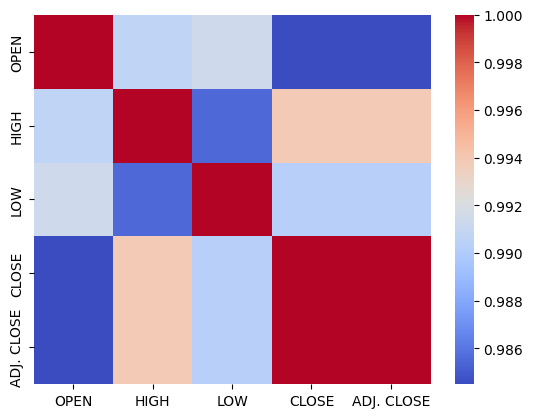

In [15]:
#Plotting a scatter plot and Correlation Matrices
plt.xlabel("OPEN")
plt.ylabel("CLOSE")
plt.title("Scatter Plot of OPEN vs CLOSE")
plt.scatter(cf["OPEN"], cf["CLOSE"])  # Access columns using bracket notation
plt.show()
#Computing the corelation between variables
#Selecting numeric columns only
numerical_cf = cf.select_dtypes(include=[np.number])
numerical_cf = numerical_cf.select_dtypes(include=[np.number])
# Compute the correlation matrix
correlation_matrix = numerical_cf.corr(method="pearson")
sns.heatmap(correlation_matrix, cmap ="coolwarm")
print(correlation_matrix)

In [16]:
sample_data = cf['HIGH']  # Testing the "HIGH" column
population_mean = 8390.06  # Assuming the "OPEN" mean as the hypothesized population mean
t_statistic, p_value = stats.ttest_1samp(sample_data, population_mean)
print(f"t-statistic: {t_statistic:.2f}")
print(f"p-value: {p_value:.3f}")
alpha = 0.05  # Significance level

if p_value < alpha:
    print("Reject the null hypothesis (the sample mean is significantly different from the population mean)")
else:
    print("Fail to reject the null hypothesis (the sample mean is not significantly different from the population mean)")

t-statistic: 1.87
p-value: 0.062
Fail to reject the null hypothesis (the sample mean is not significantly different from the population mean)


In [17]:
sample_data = cf['LOW']  # Testing the LOW column
population_mean = 8390.06  #Hypothesized population mean
t_statistic, p_value = stats.ttest_1samp(sample_data, population_mean)
print(f"t-statistic: {t_statistic:.2f}")
print(f"p-value: {p_value:.3f}")
alpha = 0.05  # Significance level

if p_value < alpha:
    print("Reject the null hypothesis (the sample mean is significantly different from the population mean)")
else:
    print("Fail to reject the null hypothesis (the sample mean is not significantly different from the population mean)")

t-statistic: -1.69
p-value: 0.092
Fail to reject the null hypothesis (the sample mean is not significantly different from the population mean)


In [18]:
sample_data = cf['CLOSE']  # Testing the "CLOSE" column.
population_mean = 8390.06  # Hypothesized population mean
t_statistic, p_value = stats.ttest_1samp(sample_data, population_mean)
print(f"t-statistic: {t_statistic:.2f}")
print(f"p-value: {p_value:.3f}")
alpha = 0.05  # Significance level

if p_value < alpha:
    print("Reject the null hypothesis (the sample mean is significantly different from the population mean)")
else:
    print("Fail to reject the null hypothesis (the sample mean is not significantly different from the population mean)")

t-statistic: 0.29
p-value: 0.770
Fail to reject the null hypothesis (the sample mean is not significantly different from the population mean)


In [19]:
sample_data = cf['ADJ. CLOSE']  # Testing the ADJ. CLOSE column
population_mean = 8390.06  # Hypothesized population mean
t_statistic, p_value = stats.ttest_1samp(sample_data, population_mean)
print(f"t-statistic: {t_statistic:.2f}")
print(f"p-value: {p_value:.3f}")
alpha = 0.05  # Significance level

if p_value < alpha:
    print("Reject the null hypothesis (the sample mean is significantly different from the population mean)")
else:
    print("Fail to reject the null hypothesis (the sample mean is not significantly different from the population mean)")

t-statistic: 0.29
p-value: 0.770
Fail to reject the null hypothesis (the sample mean is not significantly different from the population mean)


In [20]:
# Assigning the Columns
G1 = cf['OPEN']
G2 = cf['HIGH']

# The two-way t-test
t_statistic, p_value = stats.ttest_ind(G1, G2)

# Displaying the results
print(f"t-statistic: {t_statistic:.2f}")
print(f"p-value: {p_value:.3f}")

alpha = 0.05  # Significance level

if p_value < alpha:
    print("Reject the null hypothesis (there is a significant difference between the groups)")
else:
    print("Fail to reject the null hypothesis (no significant difference between the groups)")

t-statistic: -1.35
p-value: 0.179
Fail to reject the null hypothesis (no significant difference between the groups)


In [21]:
# Assigning the columns
G1 = cf['OPEN']
G2 = cf['LOW']

# The two-way t-test
t_statistic, p_value = stats.ttest_ind(G1, G2)

# Print the results
print(f"t-statistic: {t_statistic:.2f}")
print(f"p-value: {p_value:.3f}")

alpha = 0.05  # Significance level

if p_value < alpha:
    print("Reject the null hypothesis (there is a significant difference between the groups)")
else:
    print("Fail to reject the null hypothesis (no significant difference between the groups)")

t-statistic: 1.17
p-value: 0.241
Fail to reject the null hypothesis (no significant difference between the groups)


In [22]:
# Assinging the two groups
G1 = cf['OPEN']
G2 = cf['CLOSE']

# The two-way t-test
t_statistic, p_value = stats.ttest_ind(G1, G2)

# Displaying the results
print(f"t-statistic: {t_statistic:.2f}")
print(f"p-value: {p_value:.3f}")

alpha = 0.05  # Significance level

if p_value < alpha:
    print("Reject the null hypothesis (there is a significant difference between the groups)")
else:
    print("Fail to reject the null hypothesis (no significant difference between the groups)")

t-statistic: -0.21
p-value: 0.837
Fail to reject the null hypothesis (no significant difference between the groups)


In [23]:
# Defining the two groups
G1 = cf['HIGH']
G2 = cf['LOW']

#The two-way t-test
t_statistic, p_value = stats.ttest_ind(G1, G2)

# Display the results
print(f"t-statistic: {t_statistic:.2f}")
print(f"p-value: {p_value:.3f}")

alpha = 0.05  # Significance level

if p_value < alpha:
    print("Reject the null hypothesis (there is a significant difference between the groups)")
else:
    print("Fail to reject the null hypothesis (no significant difference between the groups)")

t-statistic: 2.52
p-value: 0.012
Reject the null hypothesis (there is a significant difference between the groups)


In [24]:
# Defiinig the two groups
G1 = cf['HIGH']
G2 = cf['CLOSE']

# The two-way t-test
t_statistic, p_value = stats.ttest_ind(G1, G2)

# Displaying the results
print(f"t-statistic: {t_statistic:.2f}")
print(f"p-value: {p_value:.3f}")

alpha = 0.05  # Significance level

if p_value < alpha:
    print("Reject the null hypothesis (there is a significant difference between the groups)")
else:
    print("Fail to reject the null hypothesis (no significant difference between the groups)")

t-statistic: 1.15
p-value: 0.252
Fail to reject the null hypothesis (no significant difference between the groups)


In [25]:
# Defining the two groups
G1 = cf['HIGH']
G2 = cf['ADJ. CLOSE']

# The two-way t-test
t_statistic, p_value = stats.ttest_ind(G1, G2)

# Print the results
print(f"t-statistic: {t_statistic:.2f}")
print(f"p-value: {p_value:.3f}")

# Displaying the results
alpha = 0.05  # Significance level

if p_value < alpha:
    print("Reject the null hypothesis (there is a significant difference between the groups)")
else:
    print("Fail to reject the null hypothesis (no significant difference between the groups)")

t-statistic: 1.15
p-value: 0.252
Fail to reject the null hypothesis (no significant difference between the groups)


In [26]:
# Defining the two groups
G1 = cf['LOW']
G2 = cf['CLOSE']

#The two-way t-test
t_statistic, p_value = stats.ttest_ind(G1, G2)

# Displaying the results
print(f"t-statistic: {t_statistic:.2f}")
print(f"p-value: {p_value:.3f}")

alpha = 0.05  # Significance level

if p_value < alpha:
    print("Reject the null hypothesis (there is a significant difference between the groups)")
else:
    print("Fail to reject the null hypothesis (no significant difference between the groups)")

t-statistic: -1.39
p-value: 0.166
Fail to reject the null hypothesis (no significant difference between the groups)


In [27]:
# Defining the two groups
G1 = cf['LOW']
G2 = cf['ADJ. CLOSE']

# The two-way t-test
t_statistic, p_value = stats.ttest_ind(G1, G2)

# Displaying the results
print(f"t-statistic: {t_statistic:.2f}")
print(f"p-value: {p_value:.3f}")

alpha = 0.05  # Significance level

if p_value < alpha:
    print("Reject the null hypothesis (there is a significant difference between the groups)")
else:
    print("Fail to reject the null hypothesis (no significant difference between the groups)")

t-statistic: -1.39
p-value: 0.166
Fail to reject the null hypothesis (no significant difference between the groups)


In [28]:
# Defining the two groups
G1 = cf['CLOSE']
G2 = cf['ADJ. CLOSE']

# The two-way t-test
t_statistic, p_value = stats.ttest_ind(G1, G2)

#Displaying the results
print(f"t-statistic: {t_statistic:.2f}")
print(f"p-value: {p_value:.3f}")

alpha = 0.05  # Significance level

if p_value < alpha:
    print("Reject the null hypothesis (there is a significant difference between the groups)")
else:
    print("Fail to reject the null hypothesis (no significant difference between the groups)")

t-statistic: 0.00
p-value: 1.000
Fail to reject the null hypothesis (no significant difference between the groups)


In [29]:
# Define columns
c1 = cf['OPEN']
c2 = cf['HIGH']

# The paired t-test
t_statistic, p_value = stats.ttest_rel(c1, c2)

# Displaying the results
print(f"t-statistic: {t_statistic:.2f}")
print(f"p-value: {p_value:.3f}")

alpha = 0.05  # Significance level

if p_value < alpha:
    print("Reject the null hypothesis (there is a significant difference between the paired groups)")
else:
    print("Fail to reject the null hypothesis (no significant difference between the paired groups)")

t-statistic: -13.56
p-value: 0.000
Reject the null hypothesis (there is a significant difference between the paired groups)


In [30]:
# Defining columns
c1 = cf['OPEN']
c2 = cf['CLOSE']

# The paired t-test
t_statistic, p_value = stats.ttest_rel(c1, c2)

# Displaying the results
print(f"t-statistic: {t_statistic:.2f}")
print(f"p-value: {p_value:.3f}")

alpha = 0.05  # Significance level

if p_value < alpha:
    print("Reject the null hypothesis (there is a significant difference between the paired groups)")
else:
    print("Fail to reject the null hypothesis (no significant difference between the paired groups)")

t-statistic: -1.65
p-value: 0.100
Fail to reject the null hypothesis (no significant difference between the paired groups)


In [31]:
#PERFORMING ONE-WAY ANOVA TEST
c1 = cf["OPEN"]
c2 = cf["HIGH"]
c3 = cf["LOW"]
c4 = cf["CLOSE"]
c5 = cf["ADJ. CLOSE"]

# One-way ANOVA
statistic, p_value = stats.f_oneway(c1, c2, c3, c4, c5)
print(f"F-statistic: {statistic}, p-value: {p_value}")
alpha = 0.05  # Significance level

if p_value < alpha:
    print("Reject the null hypothesis (there is a significant difference between variables)")
else:
    print("Fail to reject the null hypothesis (no significant difference between variables)")

F-statistic: 1.6116750744849626, p-value: 0.16891174054106947
Fail to reject the null hypothesis (no significant difference between variables)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   DATE        252 non-null    object 
 1   OPEN        252 non-null    float64
 2   HIGH        252 non-null    float64
 3   LOW         252 non-null    float64
 4   CLOSE       252 non-null    float64
 5   ADJ. CLOSE  252 non-null    float64
 6   VOLUME      252 non-null    object 
dtypes: float64(5), object(2)
memory usage: 13.9+ KB


<ipython-input-32-9207ae89d6d2>:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cf["DATE"] = pd.to_datetime(cf["DATE"])  # Convert "DATE" column to datetime


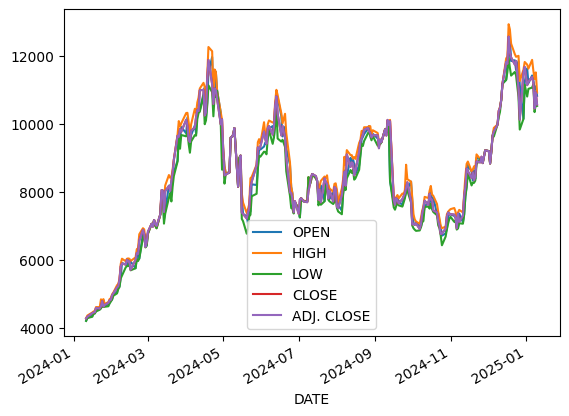

In [32]:
#PLOT OF TIME SERIES TO DETERMINE PATTERN
cf = pd.read_csv(cocoa_data, thousands=',')
cf.info()
cf["DATE"] = pd.to_datetime(cf["DATE"])  # Convert "DATE" column to datetime
cf.set_index("DATE", inplace=True)  # Set "DATE" as index
cf.plot()
plt.show()

<ipython-input-33-36dea4b8f506>:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cf["DATE"] = pd.to_datetime(cf["DATE"])  # Convert "DATE" column to datetime


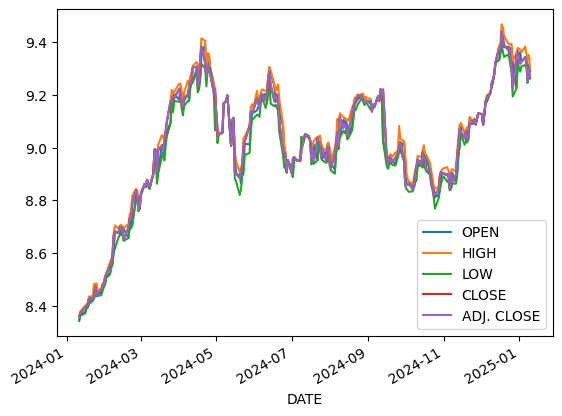

In [33]:
#TRANSFORMING THE TIME-SERIES PLOT TO STABILIZE ITS VARIANCE
cf = pd.read_csv(cocoa_data, thousands=',')  # Read the CSV file with thousands separator
cf["DATE"] = pd.to_datetime(cf["DATE"])  # Convert "DATE" column to datetime
cf.set_index("DATE", inplace=True)  # Set "DATE
# Select numerical columns for the log transformation
numerical_cols = ['OPEN', 'HIGH', 'LOW', 'CLOSE', 'ADJ. CLOSE']

# Apply log transformation only to numerical columns
cf[numerical_cols] = cf[numerical_cols].apply(pd.to_numeric, errors='coerce') # Convert to numeric, handle errors
cf[numerical_cols] = np.log(cf[numerical_cols])

cf.plot()
plt.show()

In [34]:
#Dividing the Data set into two
msk = cf.index < cf.index.max() - pd.Timedelta(days=182)
cf_train = cf[msk].copy()
cf_test = cf[~msk].copy()

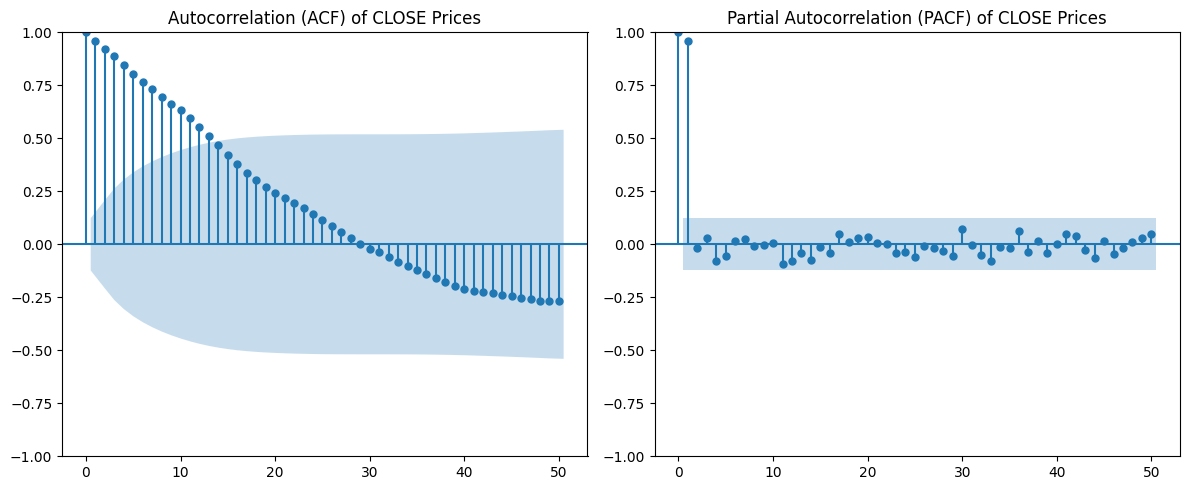

In [35]:
#PLOTTING ACF AND PACF PLOTS TO FURTHER CHECK FOR STATIONARITY OF THE TIME SERIES USING LOG DIFFERENCING
log_value = cf_train[numerical_cols] # Assign log_value to the log-transformed columns in cf_train
normal_value_np = np.exp(log_value)
# Assuming 'cf' is your DataFrame and 'CLOSE' is the column of interest
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot ACF on the first subplot
plot_acf(cf['CLOSE'], lags=50, ax=axes[0])  # Adjust 'lags' as needed
axes[0].set_title("Autocorrelation (ACF) of CLOSE Prices")

# Plot PACF on the second subplot
plot_pacf(cf['CLOSE'], lags=50, ax=axes[1])  # Adjust 'lags' as needed
axes[1].set_title("Partial Autocorrelation (PACF) of CLOSE Prices")

# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()



In [36]:
#ADF TEST TO TEST FOR STATTIONARITY
from statsmodels.tsa.stattools import adfuller
adf_test = adfuller(cf_train[numerical_cols[3]])
print(f"ADF Statistic: {adf_test[3]}")
print(f"p-value: {adf_test[3]}")

ADF Statistic: 121
p-value: 121


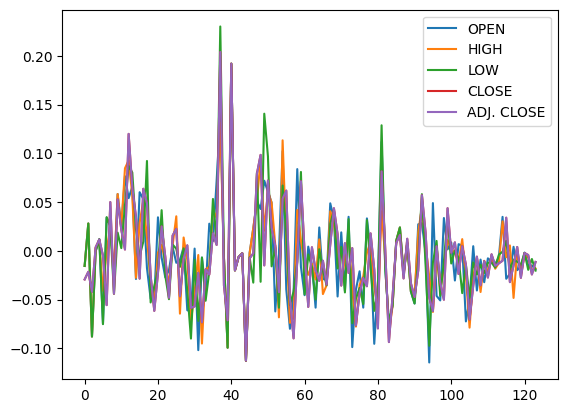

In [37]:
#TRANFORMING THE TIME SERIES FROM NON-STATIONARY INTO STATIONARY
cf_train_diff = cf_train[numerical_cols].diff()
cf_train_diff.dropna(inplace=True)
cf_train_diff = cf_train_diff.reset_index(drop=True)
cf_train_diff.plot()
plt.show()

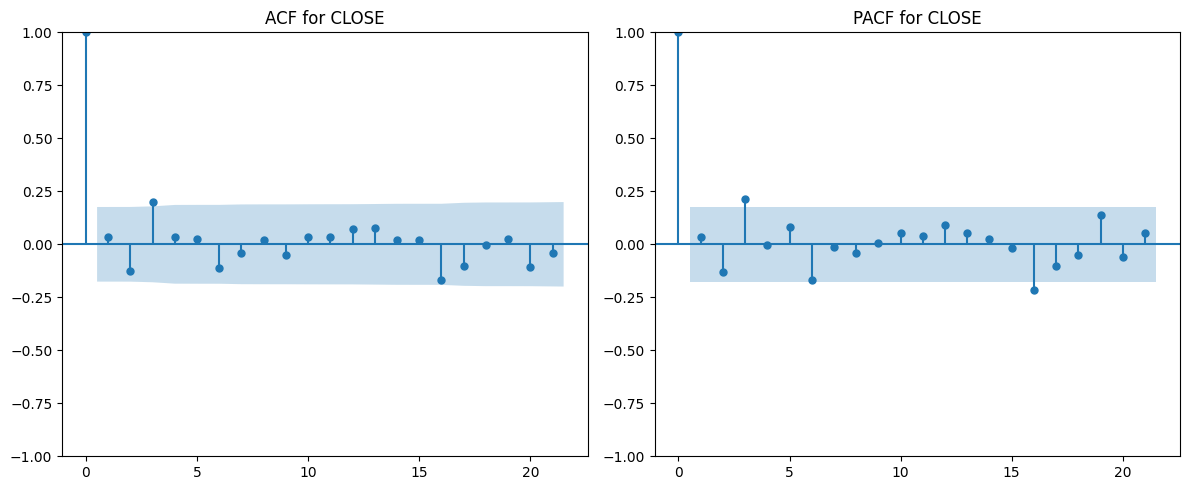

In [38]:
# NEW ACF AND PACF PLOT AFTER DIFFERENCING
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Plot ACF on the first subplot
plot_acf(cf_train_diff[numerical_cols[3]], title=f"ACF for {numerical_cols[3]}", ax=axes[0])

# Plot PACF on the second subplot
plot_pacf(cf_train_diff[numerical_cols[3]], title=f"PACF for {numerical_cols[3]}", ax=axes[1])

plt.tight_layout()
plt.show()

In [39]:
# NEW ADF TEST AFTER FIRST DIFFERENCING
afd_test = adfuller(cf_train_diff[cf_train_diff.columns[3]])  # Applying ADF test on the differenced data.
print(f"p-value: {afd_test[1]}")  # Printing the p-value

p-value: 2.430775504309711e-06


In [40]:
#FITTING THE ARIMA MODEL WITH PARAMETERS (O,1,1)
model = ARIMA(cf_train_diff[cf_train.columns[3]], order=(0, 1, 1))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  CLOSE   No. Observations:                  124
Model:                 ARIMA(0, 1, 1)   Log Likelihood                 196.605
Date:                Sun, 23 Feb 2025   AIC                           -389.210
Time:                        20:43:31   BIC                           -383.585
Sample:                             0   HQIC                          -386.925
                                - 124                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9727      0.042    -23.357      0.000      -1.054      -0.891
sigma2         0.0023      0.000     11.310      0.000       0.002       0.003
Ljung-Box (L1) (Q):                   0.04   Jarque-

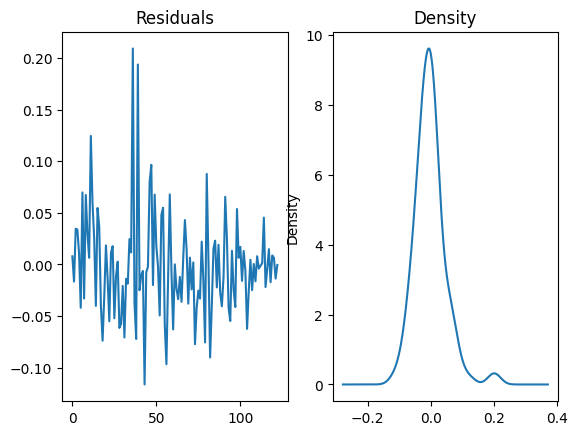

In [41]:
#PLOTTING TIME SERIES AND KDE FOR THE RESIDUALS TO CHECK THE RESIDUALS' DEPENDENCIES
residuals = model_fit.resid [1:]
fig, ax = plt.subplots(1,2)
residuals = residuals.reset_index(drop=True)
residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(kind='kde', title='Density', ax=ax[1])
plt.show()

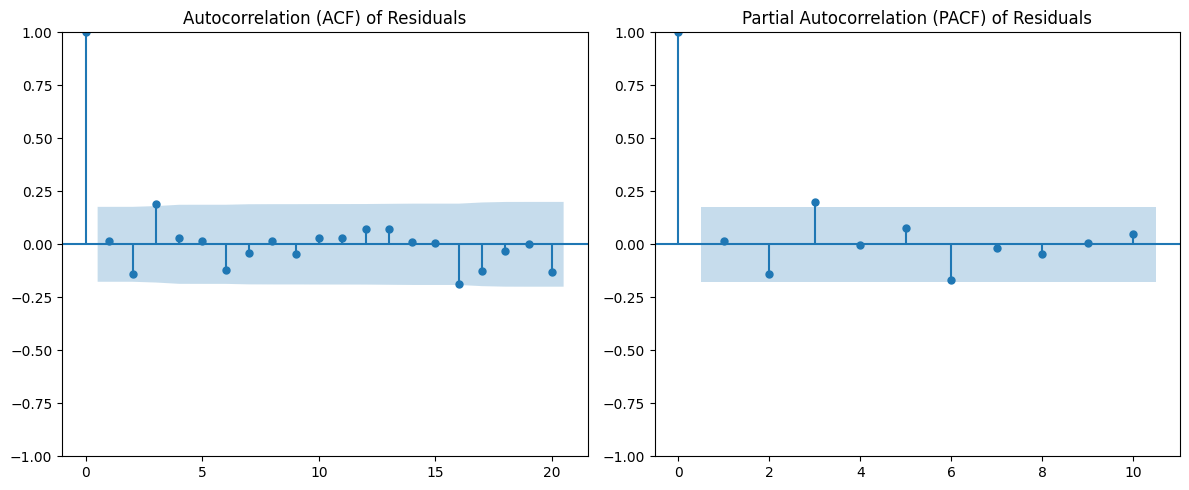

In [42]:
#PLOTTING ACF AND PACF FOR THE RESIDUALS
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot ACF of residuals on the first subplot
plot_acf(residuals, lags=20, ax=axes[0])  # Adjust 'lags' as needed
axes[0].set_title("Autocorrelation (ACF) of Residuals")

# Plot PACF of residuals on the second subplot
plot_pacf(residuals, lags=10, ax=axes[1])  # Adjust 'lags' as needed
axes[1].set_title("Partial Autocorrelation (PACF) of Residuals")

plt.tight_layout()
plt.show()

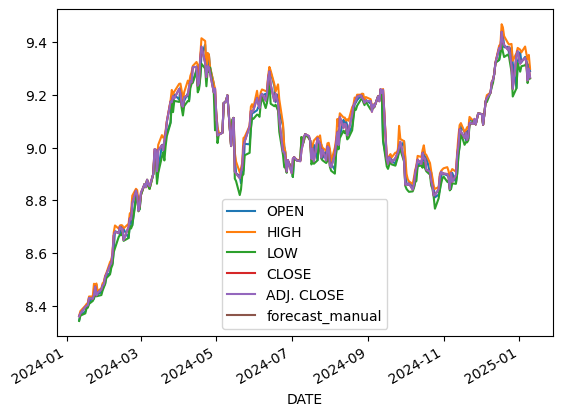

In [43]:
# FORECASTING WITH THE ARIMA MODEL(0,1,1)
# Create a column for forecast values, filled with NaN initially
cf['forecast_manual'] = np.nan

# Assign the forecasted values to the correct rows in the 'forecast_manual' column
forecast_test = model_fit.forecast(len(cf_test))
cf.loc[cf_test.index, 'forecast_manual'] = forecast_test
cf_test['forecast_manual'] = cf.loc[cf_test.index, 'forecast_manual'] #Add this line to update cf_test

cf.plot()
plt.show()


In [44]:
!pip install pmdarima
import pmdarima as pm
auto_arima_model = pm.auto_arima(cf_train_diff[cf_train.columns[3]], trace=True, suppress_warnings=True)
auto_arima_model.summary()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 20.3 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=-398.124, Time=0.41 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-397.584, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-395.737, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-395.794, Time=0.07 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-397.968, Time=0.04 sec


...

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-400.363, Time=0.21 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-397.282, Time=0.08 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-395.931, Time=0.03 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-398.413, Time=0.43 sec

Best model:  ARIMA(1,0,1)(0,0,0)[0]          
Total fit time: 2.935 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  124
Model:               SARIMAX(1, 0, 1)   Log Likelihood                 203.845
Date:                Sun, 23 Feb 2025   AIC                           -401.689
Time:                        20:44:09   BIC                           -393.228
Sample:                             0   HQIC                          -398.252
                                - 124                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7619      0.116     -6.587      0.000      -0.989      -0.535
ma.L1          0.9311      0.076     12.313      0.000       0.783       1.079
sigma2         0.0022      0.000     12.843      0.000       0.002       0.003
===================================================================================
Ljung-Box (L1) (Q):                   0.57   Jarque-Bera (JB):               117.03
Prob(Q):                              0.45   Prob(JB):                         0.00
Heteroskedasticity (H):               0.29   Skew:                             1.31
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.97
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [45]:
# Plotting the Bollinger Bands
import plotly.graph_objects as go
if 'DATE' in cf.columns:
    cf['DATE'] = pd.to_datetime(cf['DATE'])
    cf = cf.set_index('DATE')
    cf.index = pd.to_datetime(cf.index)
cf['SMA'] = cf['CLOSE'].rolling(window=20).mean()
cf['SD'] = cf['CLOSE'].rolling(window=20).std()
cf['Upper'] = cf['SMA'] + (2 * cf['SD'])
cf['Lower'] = cf['SMA'] - (2 * cf['SD'])
fig = go.Figure()
fig.add_trace(go.Scatter(x=cf.index, y=cf['CLOSE'], mode='lines', name='Close Price'))
fig.add_trace(go.Scatter(x=cf.index, y=cf['SMA'], mode='lines', name='SMA'))
fig.add_trace(go.Scatter(x=cf.index, y=cf['Upper'], mode='lines', name='Upper Band'))
fig.add_trace(go.Scatter(x=cf.index, y=cf['Lower'], mode='lines', name='Lower Band'))
fig.update_layout(title='Cocoa Prices Bollinger Bands', xaxis_title='Date', yaxis_title='Cocoa Prices', showlegend = True)
fig.show()

In [46]:
# CREATING RSI PLOT
# Calculate price differences
cf['diff'] = cf['CLOSE'].diff(1)

# Calculate gains and losses
cf['gain'] = cf['diff'].clip(lower=0).round(2)
cf['loss'] = -1 * cf['diff'].clip(upper=0).round(2)

# Calculate average gains and losses over a 14-day period
cf['avg_gain'] = cf['gain'].rolling(window=14, center=True).mean()
cf['avg_loss'] = cf['loss'].rolling(window=14, center=True).mean()

# Calculate the Relative Strength (RS)
cf['RS'] = cf['avg_gain'] / cf['avg_loss']

# Calculate the RSI
cf['RSI'] = 100 - (100 / (1 + cf['RS']))

fig_rsi = go.Figure()
fig_rsi.add_trace(go.Scatter(x=cf.index, y=cf['RSI'], mode='lines', name='RSI'))
fig_rsi.update_layout(title='RSI FOR COCOA PRICES', xaxis_title='Date', yaxis_title='RSI')

#Setting the Overbought and Oversold lines
overbought = 70
oversold = 30
fig_rsi.add_shape(go.layout.Shape(
       type="line", x0=cf.index.min(), x1=cf.index.max(), y0=overbought, y1=overbought,
       line=dict(color="Red", width=2, dash="dashdot")))
fig_rsi.add_shape(go.layout.Shape(
       type="line", x0=cf.index.min(), x1=cf.index.max(), y0=oversold, y1=oversold,
       line=dict(color="Green", width=2, dash="dashdot")))

# Show RSI plot
fig_rsi.show()